https://langchain-ai.github.io/langgraph/tutorials/multi_agent/agent_supervisor/

In [1]:
%%capture
!pip install langchain-experimental langchain_community langgraph-checkpoint-sqlite tiktoken langchain-openai langchainhub chromadb langchain langgraph tavily-python

In [3]:
from langchain_openai import AzureChatOpenAI, AzureOpenAIEmbeddings
from google.colab import userdata

llm = AzureChatOpenAI(
    model=userdata.get('AZURE_MODEL_NAME'),
    deployment_name=userdata.get('AZURE_MODEL_NAME'),
    temperature=0,
    # max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=userdata.get('AZURE_API_KEY'),  # if you prefer to pass api key in directly instaed of using env vars
    azure_endpoint=userdata.get('AZURE_BASE_URL'),
    api_version=userdata.get('AZURE_API_VERSION'),
)

emd = AzureOpenAIEmbeddings(
    model=userdata.get('AZURE_EMBEDDING_NAME'),
    api_key=userdata.get('AZURE_API_KEY'),
    azure_endpoint=userdata.get('AZURE_BASE_URL'),
    api_version=userdata.get('AZURE_API_VERSION'),
)


In [4]:
%%capture
from langchain_community.tools.tavily_search import TavilySearchResults
%env TAVILY_API_KEY={userdata.get("TAVILY_API_KEY")}

In [5]:
from typing import Annotated

from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_experimental.tools import PythonREPLTool

tavily_tool = TavilySearchResults(max_results=5)

# This executes code locally, which can be unsafe
python_repl_tool = PythonREPLTool()

In [6]:
from langchain_core.messages import HumanMessage

def agent_node(state, agent, name):
    result = agent.invoke(state)
    return {"messages": [HumanMessage(content=result["messages"][-1].content, name=name)]}

In [29]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_openai import ChatOpenAI
from pydantic import BaseModel
from typing import Literal

members = ["Researcher", "Coder"]
system_prompt = (
    "You are a supervisor tasked with managing a conversation between the"
    " following workers:  {members}. Given the following user request,"
    " respond with the worker to act next. Each worker will perform a"
    " task and respond with their results and status. When finished,"
    " respond with FINISH."
)
# Our team supervisor is an LLM node. It just picks the next agent to process
# and decides when the work is completed
options = ["FINISH"] + members

class routeResponse(BaseModel):
    next: Literal["FINISH", "Researcher", "Coder"]

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system_prompt),
        MessagesPlaceholder(variable_name="messages"),
        (
            "system",
            "Given the conversation above, who should act next?"
            " Or should we FINISH? Select one of: {options}",
        ),
    ]
).partial(options=str(options), members=", ".join(members))


def supervisor_agent(state):
    supervisor_chain = (
        prompt
        | llm.with_structured_output(routeResponse)
    )
    return supervisor_chain.invoke(state)

In [30]:
import functools
import operator
from typing import Sequence, TypedDict

from langchain_core.messages import BaseMessage

from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import create_react_agent

# The agent state is the input to each node in the graph
class AgentState(TypedDict):
    # The annotation tells the graph that new messages will always
    # be added to the current states
    messages: Annotated[Sequence[BaseMessage], operator.add]
    # The 'next' field indicates where to route to next
    next: str


research_agent = create_react_agent(llm, tools=[tavily_tool])
research_node = functools.partial(agent_node, agent=research_agent, name="Researcher")

# NOTE: THIS PERFORMS ARBITRARY CODE EXECUTION. PROCEED WITH CAUTION
code_agent = create_react_agent(llm, tools=[python_repl_tool])
code_node = functools.partial(agent_node, agent=code_agent, name="Coder")

workflow = StateGraph(AgentState)
workflow.add_node("Researcher", research_node)
workflow.add_node("Coder", code_node)
workflow.add_node("supervisor", supervisor_agent)

In [31]:
for member in members:
    # We want our workers to ALWAYS "report back" to the supervisor when done
    workflow.add_edge(member, "supervisor")
# The supervisor populates the "next" field in the graph state
# which routes to a node or finishes
conditional_map = {k: k for k in members}
conditional_map["FINISH"] = END
workflow.add_conditional_edges("supervisor", lambda x: x["next"], conditional_map)
# Finally, add entrypoint
workflow.add_edge(START, "supervisor")

graph = workflow.compile()

In [43]:
for s in graph.stream(
    {
        "messages": [
            HumanMessage(content="Code a fibonacci python fun and test 5 and print it to the terminal")
        ]
    }
):
    if "__end__" not in s:
        print(s)
        print("----")

{'supervisor': {'next': 'Coder'}}
----
{'Coder': {'messages': [HumanMessage(content='The Fibonacci sequence for \\( n = 5 \\) is: \\([0, 1, 1, 2, 3]\\).', additional_kwargs={}, response_metadata={}, name='Coder')]}}
----
{'supervisor': {'next': 'Coder'}}
----
{'Coder': {'messages': [HumanMessage(content='The Fibonacci sequence for \\( n = 5 \\) is: \\([0, 1, 1, 2, 3]\\).', additional_kwargs={}, response_metadata={}, name='Coder')]}}
----
{'supervisor': {'next': 'Coder'}}
----
{'Coder': {'messages': [HumanMessage(content='The Fibonacci sequence for \\( n = 5 \\) is: \\([0, 1, 1, 2, 3]\\).', additional_kwargs={}, response_metadata={}, name='Coder')]}}
----
{'supervisor': {'next': 'Coder'}}
----
{'Coder': {'messages': [HumanMessage(content='The Fibonacci sequence for \\( n = 5 \\) is: \\([0, 1, 1, 2, 3]\\).', additional_kwargs={}, response_metadata={}, name='Coder')]}}
----
{'supervisor': {'next': 'Coder'}}
----
{'Coder': {'messages': [HumanMessage(content='Here is the Python function to 

In [34]:
for s in graph.stream(
    {"messages": [HumanMessage(content="Write a brief research report on pikas.")]},
    {"recursion_limit": 100},
):
    if "__end__" not in s:
        print(type(s),s)
        print("----")

<class 'langgraph.pregel.io.AddableUpdatesDict'> {'supervisor': {'next': 'Researcher'}}
----
<class 'langgraph.pregel.io.AddableUpdatesDict'> {'Researcher': {'messages': [HumanMessage(content='### Research Report on Pikas\n\n#### Introduction\nPikas are small, herbivorous mammals belonging to the family Ochotonidae, within the order Lagomorpha, which also includes rabbits and hares. These creatures are known for their distinctive high-pitched calls and their adaptation to cold, mountainous environments. This report delves into their habitat, behavior, diet, reproduction, and conservation status.\n\n#### Habitat and Behavior\nPikas are primarily found in cold climates, often inhabiting rocky slopes and alpine meadows. They are well-adapted to these harsh environments, where temperatures can be extremely low. Unlike many other small mammals, pikas do not hibernate. Instead, they remain active throughout the winter by traveling in tunnels under rocks and snow, and by consuming dried plant

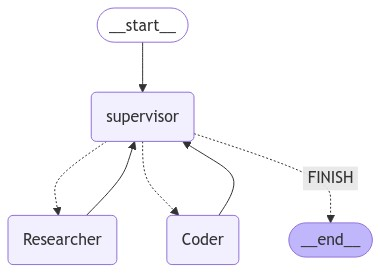

In [42]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass